<a href="https://colab.research.google.com/github/maherkh07/ecommerce-transaction-analysis/blob/main/E_commerce_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-Commerce Transaction Analysis Project
This analytics project focuses on a global software retailer selling subscriptions and products

In [57]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [58]:
#read and explore the dataset
df = pd.read_csv("/content/E-commerce Dataset - python training.csv")
df

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,unit_price_local,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason
0,DB4F1A096586,order,09/12/2024 00:11,CUST0001946,PROD0083,United States,39.8283,-98.5795,NaN,Website,...,36.70,NaN,0.0,0.00,110.10,1.00,110.10,False,NaN,NaN
1,3550A69EEA36,order,11/08/2025 21:31,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,19.70,NaN,0.0,9.85,108.35,0.66,71.51,False,NaN,NaN
2,0C3CAE65E90C,order,30/09/2025 15:39,CUST0001105,PROD0075,Canada,56.1304,-106.3468,NaN,Website,...,20.12,NaN,0.0,1.01,21.13,1.00,21.13,False,NaN,NaN
3,7DDC83355865,invoice,26/09/2024 04:13,CUST0003164,PROD0017,United States,39.8283,-98.5795,NaN,Partner,...,19.00,NaN,0.0,0.00,190.00,1.00,190.00,False,NaN,NaN
4,DAE0B37D8815,order,23/06/2024 16:03,CUST0003410,PROD0099,United States,39.8283,-98.5795,NaN,Website,...,29.38,NaN,0.0,0.00,88.14,1.00,88.14,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48383,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#**Data Cleaning Phase**
exploring and cleaning the data to be ready for analysis

In [59]:
#check for missing values
df.isnull().sum()

,0
event_id,369
event_type,369
event_date,369
customer_id,369
product_id,369
country,369
latitude,369
longitude,369
region,19955
channel,369


In [60]:
#explore nulls

event_id_nulls = df[df["event_id"].isnull()]
event_id_nulls

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,unit_price_local,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason
63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48383,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
#drop nulls

clean_df = df.dropna(subset=["event_id"]).reset_index(drop=True)
clean_df

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,unit_price_local,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason
0,DB4F1A096586,order,09/12/2024 00:11,CUST0001946,PROD0083,United States,39.8283,-98.5795,NaN,Website,...,36.70,NaN,0.00,0.00,110.10,1.00,110.10,False,NaN,NaN
1,3550A69EEA36,order,11/08/2025 21:31,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,19.70,NaN,0.00,9.85,108.35,0.66,71.51,False,NaN,NaN
2,0C3CAE65E90C,order,30/09/2025 15:39,CUST0001105,PROD0075,Canada,56.1304,-106.3468,NaN,Website,...,20.12,NaN,0.00,1.01,21.13,1.00,21.13,False,NaN,NaN
3,7DDC83355865,invoice,26/09/2024 04:13,CUST0003164,PROD0017,United States,39.8283,-98.5795,NaN,Partner,...,19.00,NaN,0.00,0.00,190.00,1.00,190.00,False,NaN,NaN
4,DAE0B37D8815,order,23/06/2024 16:03,CUST0003410,PROD0099,United States,39.8283,-98.5795,NaN,Website,...,29.38,NaN,0.00,0.00,88.14,1.00,88.14,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48014,CC2724785D44,invoice,27/04/2024 03:18,CUST0001573,PROD0089,Brazil,-14.2350,-51.9253,LATAM,Direct Sales,...,23.45,SAVE5,11.73,35.17,257.94,1.00,257.94,False,NaN,NaN
48015,8F721B3A7EB9,invoice,08/08/2025 13:17,CUST0003496,PROD0048,Netherlands,52.1326,5.2913,EU,Partner,...,84.91,NaN,0.00,169.82,1018.92,1.06,1080.06,False,NaN,NaN
48016,31681CA1A687,order,19/11/2024 05:37,CUST0001408,PROD0032,Philippines,12.8797,121.7740,APAC,Website,...,120.00,NaN,0.00,54.00,414.00,1.00,414.00,False,NaN,NaN
48017,E5332EABFA60,order,07/03/2025 11:57,CUST0002137,PROD0077,Brazil,-14.2350,-51.9253,LATAM,Website,...,25.00,NEWCUSTOMER10,7.50,11.25,78.75,1.00,78.75,False,NaN,NaN


In [62]:
#check for dublicates in event id
clean_df.duplicated(subset="event_id").sum()

np.int64(19)

In [63]:
#explore duplicates in event id
clean_df[clean_df.duplicated(subset="event_id")]

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,unit_price_local,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason
205,992673EC71FA,order,14/08/2025 01:34,CUST0003215,PROD0025,United States,39.8283,-98.5795,NaN,Reseller,...,29.00,NEWCUSTOMER10,29.00,0.00,261.00,1.00,261.00,False,NaN,NaN
206,56E390C9F361,invoice,15/05/2025 02:20,CUST0003336,PROD0023,United States,39.8283,-98.5795,NaN,Website,...,8.00,WELCOME10,0.80,0.00,7.20,1.00,7.20,False,NaN,NaN
207,FE115B446117,order,06/03/2025 07:56,CUST0002488,PROD0062,United Kingdom,55.3781,-3.4360,EU,Reseller,...,184.55,NaN,0.00,36.91,221.46,1.22,270.18,False,NaN,NaN
208,9280ED6200CB,order,19/02/2025 20:44,CUST0000336,PROD0063,Netherlands,52.1326,5.2913,EU,Marketplace,...,9.32,NaN,0.00,1.86,11.18,1.06,11.85,False,NaN,NaN
209,3FAB70AAC5AA,invoice,04/06/2024 10:10,CUST0000961,PROD0037,Germany,51.1657,10.4515,EU,Website,...,11.79,NaN,0.00,11.79,70.74,1.06,74.98,False,NaN,NaN
210,CDC342D5C228,invoice,09/09/2025 22:25,CUST0003753,PROD0095,Australia,-25.2744,133.7751,APAC,Reseller,...,29.74,NEWCUSTOMER10,59.48,59.48,594.80,0.66,392.57,False,NaN,NaN
211,B36D376C16D2,invoice,07/09/2025 12:41,CUST0000497,PROD0020,United States,39.8283,-98.5795,NaN,Website,...,144.00,NaN,0.00,0.00,144.00,1.00,144.00,False,NaN,NaN
212,30962C377FE2,invoice,10/06/2024 04:08,CUST0001308,PROD0006,Australia,-25.2744,133.7751,APAC,Partner,...,225.76,NaN,0.00,22.58,248.34,0.66,163.90,False,NaN,NaN
213,4D7327537F77,order,10/11/2024 19:58,CUST0002297,PROD0001,Canada,56.1304,-106.3468,NaN,Website,...,49.00,LOYALTY15,7.35,2.45,44.10,1.00,44.10,False,NaN,NaN
214,6433A0A807E8,order,04/06/2025 07:14,CUST0001760,PROD0086,Germany,51.1657,10.4515,EU,Website,...,212.41,WELCOME10,212.41,424.82,2336.51,1.06,2476.70,False,NaN,NaN


In [64]:
#drop dublicates in event id
clean_df = clean_df.drop_duplicates(subset=["event_id"]).reset_index(drop=True)
clean_df

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,unit_price_local,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason
0,DB4F1A096586,order,09/12/2024 00:11,CUST0001946,PROD0083,United States,39.8283,-98.5795,NaN,Website,...,36.70,NaN,0.00,0.00,110.10,1.00,110.10,False,NaN,NaN
1,3550A69EEA36,order,11/08/2025 21:31,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,19.70,NaN,0.00,9.85,108.35,0.66,71.51,False,NaN,NaN
2,0C3CAE65E90C,order,30/09/2025 15:39,CUST0001105,PROD0075,Canada,56.1304,-106.3468,NaN,Website,...,20.12,NaN,0.00,1.01,21.13,1.00,21.13,False,NaN,NaN
3,7DDC83355865,invoice,26/09/2024 04:13,CUST0003164,PROD0017,United States,39.8283,-98.5795,NaN,Partner,...,19.00,NaN,0.00,0.00,190.00,1.00,190.00,False,NaN,NaN
4,DAE0B37D8815,order,23/06/2024 16:03,CUST0003410,PROD0099,United States,39.8283,-98.5795,NaN,Website,...,29.38,NaN,0.00,0.00,88.14,1.00,88.14,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,CC2724785D44,invoice,27/04/2024 03:18,CUST0001573,PROD0089,Brazil,-14.2350,-51.9253,LATAM,Direct Sales,...,23.45,SAVE5,11.73,35.17,257.94,1.00,257.94,False,NaN,NaN
47996,8F721B3A7EB9,invoice,08/08/2025 13:17,CUST0003496,PROD0048,Netherlands,52.1326,5.2913,EU,Partner,...,84.91,NaN,0.00,169.82,1018.92,1.06,1080.06,False,NaN,NaN
47997,31681CA1A687,order,19/11/2024 05:37,CUST0001408,PROD0032,Philippines,12.8797,121.7740,APAC,Website,...,120.00,NaN,0.00,54.00,414.00,1.00,414.00,False,NaN,NaN
47998,E5332EABFA60,order,07/03/2025 11:57,CUST0002137,PROD0077,Brazil,-14.2350,-51.9253,LATAM,Website,...,25.00,NEWCUSTOMER10,7.50,11.25,78.75,1.00,78.75,False,NaN,NaN


In [65]:
#split event_date to eventdate and eventtime
clean_df[['event_date', 'event_time']] = clean_df['event_date'].str.split(' ', expand=True)
clean_df

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason,event_time
0,DB4F1A096586,order,09/12/2024,CUST0001946,PROD0083,United States,39.8283,-98.5795,NaN,Website,...,NaN,0.00,0.00,110.10,1.00,110.10,False,NaN,NaN,00:11
1,3550A69EEA36,order,11/08/2025,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,NaN,0.00,9.85,108.35,0.66,71.51,False,NaN,NaN,21:31
2,0C3CAE65E90C,order,30/09/2025,CUST0001105,PROD0075,Canada,56.1304,-106.3468,NaN,Website,...,NaN,0.00,1.01,21.13,1.00,21.13,False,NaN,NaN,15:39
3,7DDC83355865,invoice,26/09/2024,CUST0003164,PROD0017,United States,39.8283,-98.5795,NaN,Partner,...,NaN,0.00,0.00,190.00,1.00,190.00,False,NaN,NaN,04:13
4,DAE0B37D8815,order,23/06/2024,CUST0003410,PROD0099,United States,39.8283,-98.5795,NaN,Website,...,NaN,0.00,0.00,88.14,1.00,88.14,False,NaN,NaN,16:03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,CC2724785D44,invoice,27/04/2024,CUST0001573,PROD0089,Brazil,-14.2350,-51.9253,LATAM,Direct Sales,...,SAVE5,11.73,35.17,257.94,1.00,257.94,False,NaN,NaN,03:18
47996,8F721B3A7EB9,invoice,08/08/2025,CUST0003496,PROD0048,Netherlands,52.1326,5.2913,EU,Partner,...,NaN,0.00,169.82,1018.92,1.06,1080.06,False,NaN,NaN,13:17
47997,31681CA1A687,order,19/11/2024,CUST0001408,PROD0032,Philippines,12.8797,121.7740,APAC,Website,...,NaN,0.00,54.00,414.00,1.00,414.00,False,NaN,NaN,05:37
47998,E5332EABFA60,order,07/03/2025,CUST0002137,PROD0077,Brazil,-14.2350,-51.9253,LATAM,Website,...,NEWCUSTOMER10,7.50,11.25,78.75,1.00,78.75,False,NaN,NaN,11:57


In [66]:
empty_region = clean_df[clean_df["region"].isnull()]
empty_region

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason,event_time
0,DB4F1A096586,order,09/12/2024,CUST0001946,PROD0083,United States,39.8283,-98.5795,NaN,Website,...,NaN,0.0,0.00,110.10,1.0,110.10,False,NaN,NaN,00:11
2,0C3CAE65E90C,order,30/09/2025,CUST0001105,PROD0075,Canada,56.1304,-106.3468,NaN,Website,...,NaN,0.0,1.01,21.13,1.0,21.13,False,NaN,NaN,15:39
3,7DDC83355865,invoice,26/09/2024,CUST0003164,PROD0017,United States,39.8283,-98.5795,NaN,Partner,...,NaN,0.0,0.00,190.00,1.0,190.00,False,NaN,NaN,04:13
4,DAE0B37D8815,order,23/06/2024,CUST0003410,PROD0099,United States,39.8283,-98.5795,NaN,Website,...,NaN,0.0,0.00,88.14,1.0,88.14,False,NaN,NaN,16:03
5,E3F98CFBAF5C,order,18/03/2025,CUST0001294,PROD0026,United States,39.8283,-98.5795,NaN,Website,...,NaN,0.0,0.00,7225.00,1.0,7225.00,False,NaN,NaN,12:36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47980,3D74C641DA25,order,29/08/2024,CUST0002936,PROD0090,United States,39.8283,-98.5795,NaN,Website,...,NaN,0.0,0.00,153.78,1.0,153.78,False,NaN,NaN,12:34
47983,960689CA523A,order,22/02/2025,CUST0003152,PROD0088,United States,39.8283,-98.5795,NaN,Website,...,NaN,0.0,0.00,768.90,1.0,768.90,False,NaN,NaN,09:44
47989,1EFD4B67B25A,order,09/10/2025,CUST0003593,PROD0016,Canada,56.1304,-106.3468,NaN,Direct Sales,...,NaN,0.0,78.75,1653.75,1.0,1653.75,False,NaN,NaN,09:55
47990,BC0084FCA48E,order,01/08/2025,CUST0003861,PROD0092,United States,39.8283,-98.5795,NaN,Website,...,NaN,0.0,0.00,2349.50,1.0,2349.50,False,NaN,NaN,06:16


In [67]:
empty_region["country"].unique()

array(['United States', 'Canada'], dtype=object)

In [68]:
clean_df.loc[(clean_df['region'].isnull()) & (clean_df['country'].isin(['United States', 'Canada'])), 'region'] = 'NAMER'
clean_df

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason,event_time
0,DB4F1A096586,order,09/12/2024,CUST0001946,PROD0083,United States,39.8283,-98.5795,NAMER,Website,...,NaN,0.00,0.00,110.10,1.00,110.10,False,NaN,NaN,00:11
1,3550A69EEA36,order,11/08/2025,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,NaN,0.00,9.85,108.35,0.66,71.51,False,NaN,NaN,21:31
2,0C3CAE65E90C,order,30/09/2025,CUST0001105,PROD0075,Canada,56.1304,-106.3468,NAMER,Website,...,NaN,0.00,1.01,21.13,1.00,21.13,False,NaN,NaN,15:39
3,7DDC83355865,invoice,26/09/2024,CUST0003164,PROD0017,United States,39.8283,-98.5795,NAMER,Partner,...,NaN,0.00,0.00,190.00,1.00,190.00,False,NaN,NaN,04:13
4,DAE0B37D8815,order,23/06/2024,CUST0003410,PROD0099,United States,39.8283,-98.5795,NAMER,Website,...,NaN,0.00,0.00,88.14,1.00,88.14,False,NaN,NaN,16:03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,CC2724785D44,invoice,27/04/2024,CUST0001573,PROD0089,Brazil,-14.2350,-51.9253,LATAM,Direct Sales,...,SAVE5,11.73,35.17,257.94,1.00,257.94,False,NaN,NaN,03:18
47996,8F721B3A7EB9,invoice,08/08/2025,CUST0003496,PROD0048,Netherlands,52.1326,5.2913,EU,Partner,...,NaN,0.00,169.82,1018.92,1.06,1080.06,False,NaN,NaN,13:17
47997,31681CA1A687,order,19/11/2024,CUST0001408,PROD0032,Philippines,12.8797,121.7740,APAC,Website,...,NaN,0.00,54.00,414.00,1.00,414.00,False,NaN,NaN,05:37
47998,E5332EABFA60,order,07/03/2025,CUST0002137,PROD0077,Brazil,-14.2350,-51.9253,LATAM,Website,...,NEWCUSTOMER10,7.50,11.25,78.75,1.00,78.75,False,NaN,NaN,11:57


#**Data Analysis Phase**



##1.   Demographic Analysis



In [69]:
#No. of regions in the dataset
clean_df["region"].nunique()

4

In [70]:
#explore regions
clean_df["region"].unique()

array(['NAMER', 'APAC', 'EU', 'LATAM'], dtype=object)

In [71]:
# No. of Orders per region

df_orders = clean_df[clean_df["event_type"] == "order"].copy()
orders_per_region = df_orders["region"].value_counts()
orders_per_region

,count
region,
NAMER,13714
EU,13299
APAC,5096
LATAM,1492


##Orders per Rigon

/tmp/ipykernel_5309/3216146241.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_per_region.values, y=orders_per_region.index, palette='Blues_r', ax=axes[0])


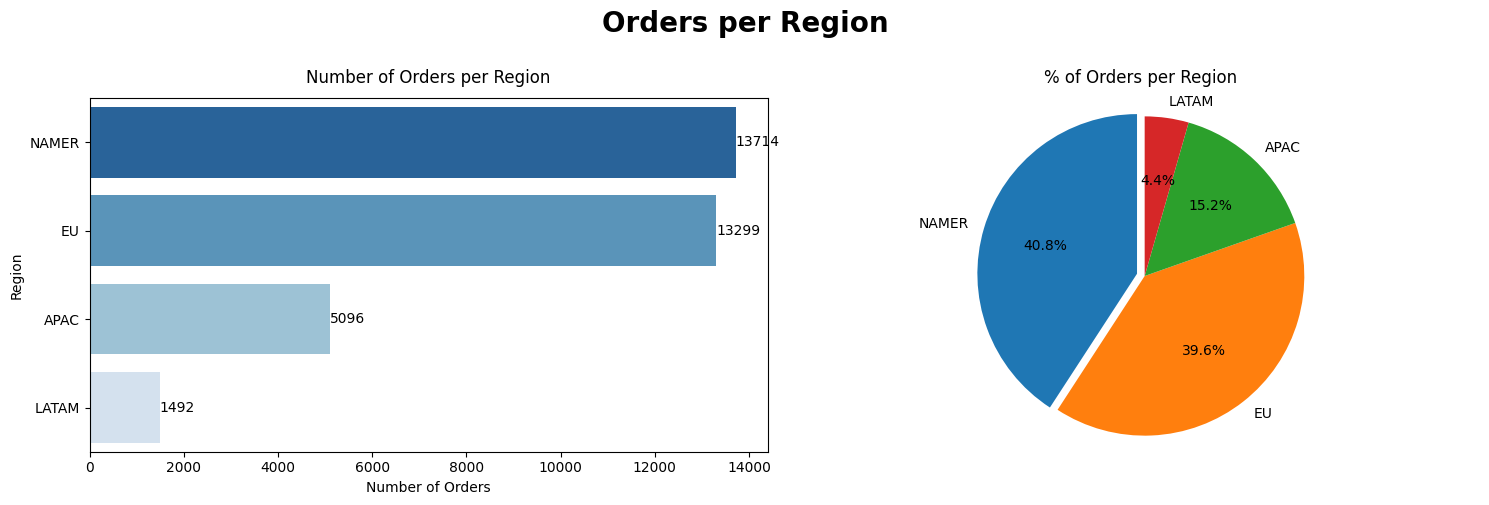

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Horizontal Bar Plot
sns.barplot(x=orders_per_region.values, y=orders_per_region.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Number of Orders per Region',y=1.02)
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Region')
for index, value in enumerate(orders_per_region.values):
    axes[0].text(value, index, str(value), va='center')

# Pie Chart
explode = (0.05, 0, 0, 0) # Emphasize the largest slice if desired
axes[1].pie(orders_per_region.values, labels=orders_per_region.index, autopct='%1.1f%%', startangle=90, explode=explode)
axes[1].set_title('% of Orders per Region',y=1.02)
axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.suptitle("Orders per Region", fontweight="bold", fontsize="20", y=1)
plt.tight_layout()
plt.show()

##Orders per Country

In [73]:
#No. of countries in the dataset
clean_df["country"].nunique()

10

In [74]:
#explore countries in the dataset
clean_df["country"].unique()

array(['United States', 'Australia', 'Canada', 'Germany', 'Brazil',
       'United Kingdom', 'France', 'Philippines', 'Spain', 'Netherlands'],
      dtype=object)

In [75]:
# No. of Orders per Country

orders_per_country = clean_df[clean_df["event_type"] == "order"]["country"].value_counts()
orders_per_country

,count
country,
United States,10348
United Kingdom,5097
Australia,3376
Canada,3366
Germany,2514
France,2310
Netherlands,1765
Philippines,1720
Spain,1613


/tmp/ipykernel_5309/3667257463.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_per_country.values, y=orders_per_country.index, palette='Blues_r', ax=axes[0])


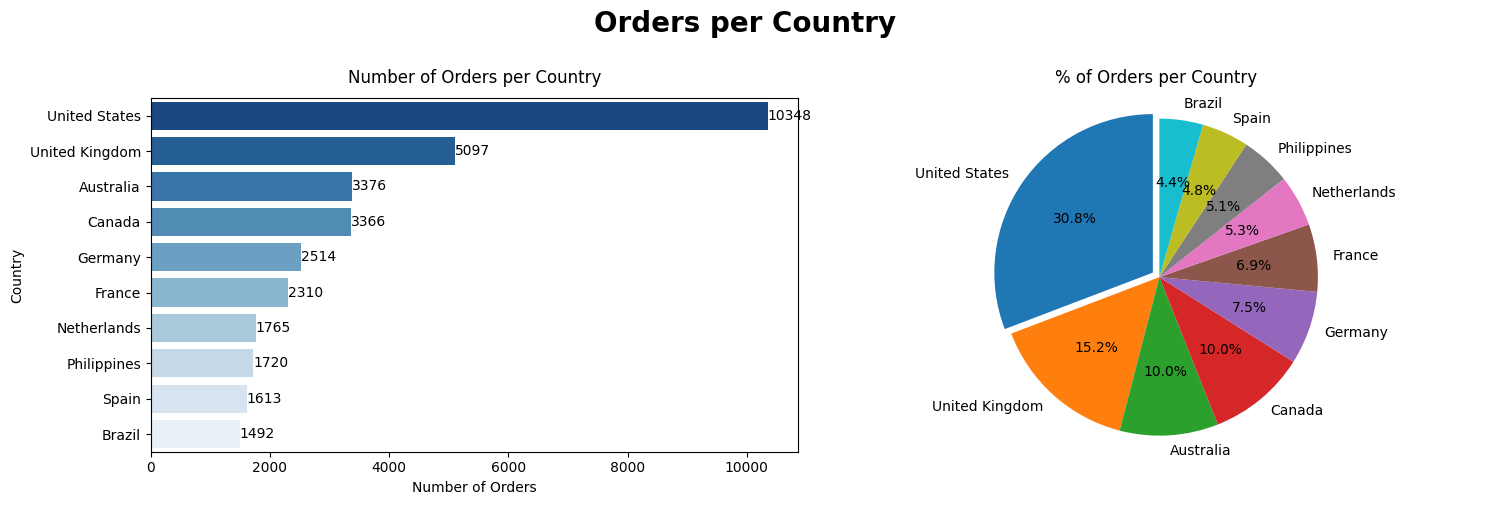

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Horizontal Bar Plot
sns.barplot(x=orders_per_country.values, y=orders_per_country.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Number of Orders per Country',y=1.02)
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Country')
for index, value in enumerate(orders_per_country.values):
    axes[0].text(value, index, str(value), va='center')

# Pie Chart
explode = (0.05,0,0,0,0,0,0,0,0,0) # Emphasize the largest slice if desired
axes[1].pie(orders_per_country.values, labels=orders_per_country.index, autopct='%1.1f%%', startangle=90, explode=explode)
axes[1].set_title('% of Orders per Country',y=1.02)
axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.suptitle("Orders per Country", fontweight="bold", fontsize="20", y=1)
plt.tight_layout()
plt.show()

##Revenue by Region

In [84]:
revenue_per_region = df_orders.groupby("region")["net_revenue_usd"].sum().sort_values(ascending=False)
revenue_per_region.map("{:,.2f}".format)

,net_revenue_usd
region,
EU,"9,626,903.26"
NAMER,"8,307,850.65"
APAC,"3,436,221.06"
LATAM,"1,082,703.99"


/tmp/ipykernel_5309/1838582832.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_per_region.values, y=revenue_per_region.index, palette='Blues_r', ax=axes[0])


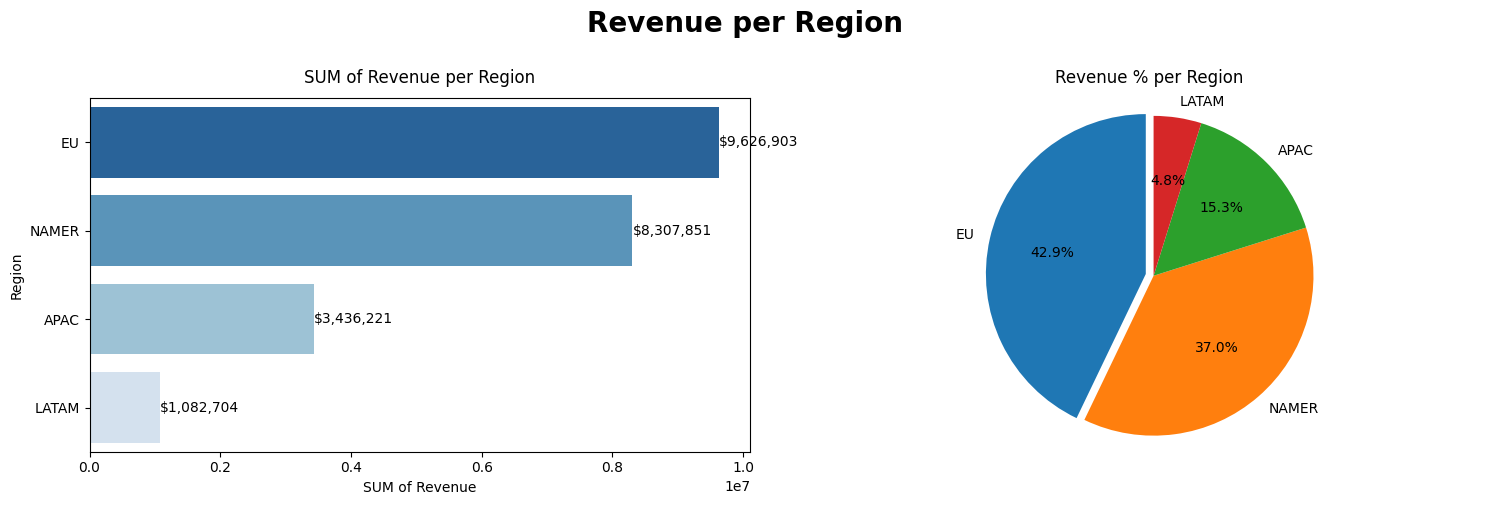

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Horizontal Bar Plot
sns.barplot(x=revenue_per_region.values, y=revenue_per_region.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('SUM of Revenue per Region',y=1.02)
axes[0].set_xlabel('SUM of Revenue')
axes[0].set_ylabel('Region')
for index, value in enumerate(revenue_per_region.values):
    formatted_value = f"${value:,.0f}"
    axes[0].text(value, index, formatted_value, va='center')

# Pie Chart
explode = (0.05, 0, 0, 0) # Emphasize the largest slice if desired
axes[1].pie(revenue_per_region.values, labels=revenue_per_region.index, autopct='%1.1f%%', startangle=90, explode=explode)
axes[1].set_title('Revenue % per Region',y=1.02)
axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.suptitle("Revenue per Region", fontweight="bold", fontsize="20", y=1)
plt.tight_layout()
plt.show()


##2. Orders

In [78]:
#number of unique orders

df_orders["product_id"].nunique()

101